In [1]:
# Mushroom Classification: Predicting edible or poisonous mushrooms

In [2]:
# Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load dataset
df = pd.read_csv("mushrooms.csv")

In [4]:
# Clean up dataset

# Looped through data to find 2480 rows with '?' data
# for col in df.columns:
#    if (df[col] == '?').any():
#        count = (df[col] == '?').sum()
#        print(f"  {col}: {count} rows with '?'")

# Drop the col stalk-root as many of its rows have '?'
df_clean = df.drop(columns=["stalk-root"])

# Feed features and target by converting categorical data to numbers 
# Used to predict the class col
# edible = 0, poisonous = 1
y = df_clean["class"].map({"e": 0, "p": 1})
X_text = df_clean.drop(columns=["class"])

# One-hot encoding since Scikit-learn's Logistic Regression and k-NN cannot accept text data
X = pd.get_dummies(X_text)

In [5]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# Train 3 Models

# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
# Logistic Regression Model (#1)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Decision Tree Model (#2)
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# k-Nearest Neighbors Model (#3) where k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
# Evaluation

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dtree,
    "k-NN (k=5)": knn,
}

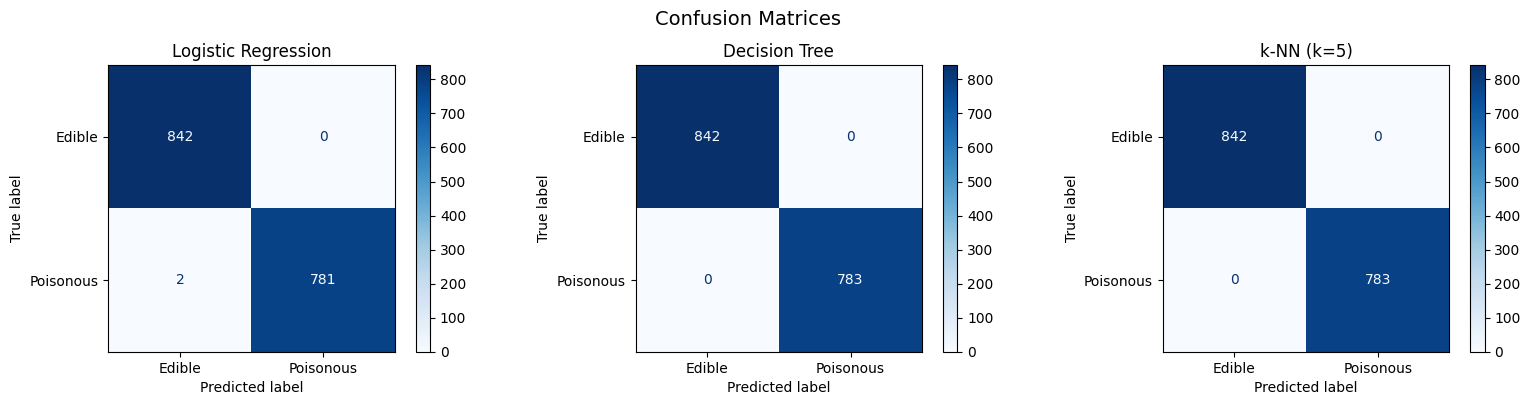

In [9]:
# Confusion matrices
# Shows where each model got things right or wrong
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Edible", "Poisonous"]).plot(ax=ax, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Classification report for each model 
# Shows precision, recall, and F1-score
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=["Edible", "Poisonous"]))
print(f"{'Model':<25} {'Train Acc':<12} {'Test Acc':<12}")
print("=" * 55)
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<25} {train_acc:<12.4f} {test_acc:<12.4f}")
print("=" * 55)


  Logistic Regression
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


  Decision Tree
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


  k-NN (k=5)
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1

In [11]:
# Cross-Validation
# Trains and tests 5 times on different splits and averages the results
from sklearn.model_selection import cross_val_score
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name:<25} Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

Logistic Regression       Mean: 0.9994  Std: 0.0012
Decision Tree             Mean: 0.9997  Std: 0.0006
k-NN (k=5)                Mean: 0.9997  Std: 0.0006
